# PitchIQ — Exploratory Data Analysis

**Premier League match data · seasons 2023/24 – 2026/27**

This notebook explores the ingested match dataset with one goal in mind: understanding the
structure of the data well enough to make defensible modeling decisions later.

Three questions drive the analysis:

1. **How strong is home advantage, and is it stable over time?** It is the single most
   important prior in any match-outcome model.
2. **Do goals follow a Poisson distribution?** If they do, a Poisson regression is a
   principled starting point rather than an arbitrary choice.
3. **How much do teams differ in attack and defense?** These become the model's features.


## 1. Setup

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# Visual style — consistent across every chart in the notebook.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

print(f"Reading from: {DATA_DIR}")

Reading from: c:\Users\Juan Andres\pitchiq\data\processed


## 2. Load and combine seasons

In [3]:
files = sorted(DATA_DIR.glob("pl_matches_*.csv"))
print(f"Found {len(files)} season files:")
for f in files:
    print(f"  - {f.name}")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df["utc_date"] = pd.to_datetime(df["utc_date"])
df["match_date"] = pd.to_datetime(df["match_date"])

print(f"\nTotal rows: {len(df):,}")

Found 4 season files:
  - pl_matches_2023.csv
  - pl_matches_2024.csv
  - pl_matches_2025.csv
  - pl_matches_2026.csv

Total rows: 1,520


In [4]:
# Separate played matches from upcoming fixtures.
# Everything analytical below uses `played`; `upcoming` is what the model will predict.
played = df[df["status"] == "FINISHED"].copy()
upcoming = df[df["status"] != "FINISHED"].copy()

print(f"Played matches:   {len(played):,}")
print(f"Upcoming fixtures: {len(upcoming):,}")
print(f"\nSeasons available: {sorted(played['season'].unique())}")

Played matches:   1,155
Upcoming fixtures: 365

Seasons available: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 3. Data quality check

Before drawing any conclusion, confirm the data is trustworthy.

In [5]:
quality = pd.DataFrame({
    "dtype": played.dtypes.astype(str),
    "nulls": played.isna().sum(),
    "null_pct": (played.isna().mean() * 100).round(2),
    "unique": played.nunique(),
})
quality

,dtype,nulls,null_pct,unique
match_id,int64,0,0.0,1155
season,int64,0,0.0,4
matchday,int64,0,0.0,38
utc_date,"datetime64[us, UTC]",0,0.0,691
status,str,0,0.0,1
stage,str,0,0.0,1
home_team,str,0,0.0,26
home_team_id,int64,0,0.0,26
away_team,str,0,0.0,26
away_team_id,int64,0,0.0,26


In [6]:
# Each Premier League season should contain exactly 380 matches (20 teams x 38 rounds).
season_counts = played.groupby("season").size().rename("matches_played")
season_counts = season_counts.to_frame()
season_counts["complete"] = season_counts["matches_played"] == 380
season_counts

,matches_played,complete
season,,
2023,380,True
2024,380,True
2025,380,True
2026,15,False


In [7]:
# Sanity checks that would invalidate the analysis if they failed.
checks = {
    "Duplicate match IDs": played["match_id"].duplicated().sum(),
    "Teams playing themselves": (played["home_team"] == played["away_team"]).sum(),
    "Negative scores": ((played["home_goals"] < 0) | (played["away_goals"] < 0)).sum(),
    "Result flag inconsistent with score": (
        played["result"] != np.select(
            [played["home_goals"] > played["away_goals"],
             played["home_goals"] < played["away_goals"]],
            ["H", "A"], default="D")
    ).sum(),
}

for label, value in checks.items():
    status = "PASS" if value == 0 else f"FAIL ({value})"
    print(f"{status:<12} {label}")

PASS         Duplicate match IDs
PASS         Teams playing themselves
PASS         Negative scores
PASS         Result flag inconsistent with score


## 4. Home advantage

Home advantage is the strongest known effect in football. Quantifying it here establishes the
baseline any model must beat — if a model can't outperform "always predict the home team,"
it isn't learning anything.

In [8]:
result_counts = played["result"].value_counts(normalize=True).sort_index()
result_labels = {"H": "Home win", "D": "Draw", "A": "Away win"}

summary = pd.DataFrame({
    "outcome": [result_labels[k] for k in result_counts.index],
    "share": (result_counts.values * 100).round(1),
    "matches": played["result"].value_counts().sort_index().values,
})
summary

,outcome,share,matches
0,Away win,32.2,372
1,Draw,24.3,281
2,Home win,43.5,502


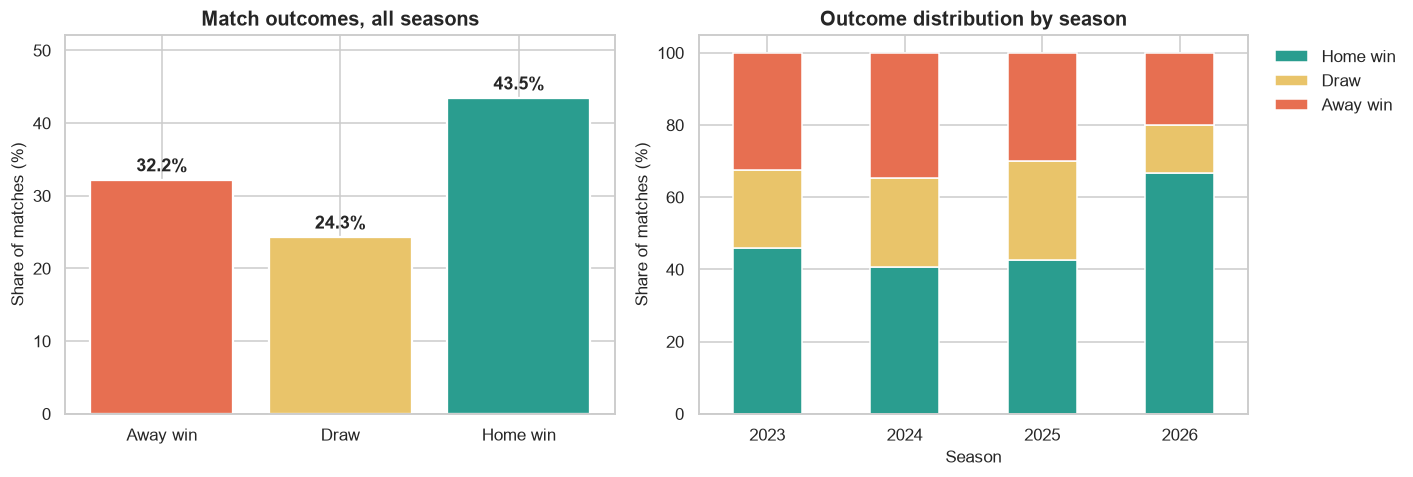

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Overall outcome distribution
colors = {"H": "#2a9d8f", "D": "#e9c46a", "A": "#e76f51"}
bars = axes[0].bar(
    [result_labels[k] for k in result_counts.index],
    result_counts.values * 100,
    color=[colors[k] for k in result_counts.index],
    edgecolor="white", linewidth=1.5,
)
axes[0].bar_label(bars, fmt="%.1f%%", padding=3, fontweight="bold")
axes[0].set_title("Match outcomes, all seasons")
axes[0].set_ylabel("Share of matches (%)")
axes[0].set_ylim(0, max(result_counts.values * 100) * 1.2)

# Stability across seasons
by_season = (
    played.groupby(["season", "result"]).size()
    .unstack(fill_value=0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)
)
by_season = by_season[["H", "D", "A"]]
by_season.plot(kind="bar", stacked=True, ax=axes[1],
               color=[colors[c] for c in by_season.columns],
               edgecolor="white", linewidth=1)
axes[1].set_title("Outcome distribution by season")
axes[1].set_ylabel("Share of matches (%)")
axes[1].set_xlabel("Season")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend([result_labels[c] for c in by_season.columns],
               bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

In [10]:
# Home advantage expressed in goals — the quantity a Poisson model will estimate directly.
home_avg = played["home_goals"].mean()
away_avg = played["away_goals"].mean()

print(f"Average goals scored at home: {home_avg:.3f}")
print(f"Average goals scored away:    {away_avg:.3f}")
print(f"Home advantage:               +{home_avg - away_avg:.3f} goals per match")
print(f"Relative uplift:              {(home_avg / away_avg - 1) * 100:.1f}%")

# Is the difference statistically meaningful, or could it be noise?
t_stat, p_value = stats.ttest_rel(played["home_goals"], played["away_goals"])
print(f"\nPaired t-test: t = {t_stat:.2f}, p = {p_value:.2e}")

Average goals scored at home: 1.622
Average goals scored away:    1.372
Home advantage:               +0.249 goals per match
Relative uplift:              18.2%

Paired t-test: t = 4.55, p = 5.83e-06


## 5. Goal distribution

The central modeling question. If goals scored by a team in a match are approximately Poisson
distributed, then Poisson regression is the natural model class — not a default, but a
justified choice.

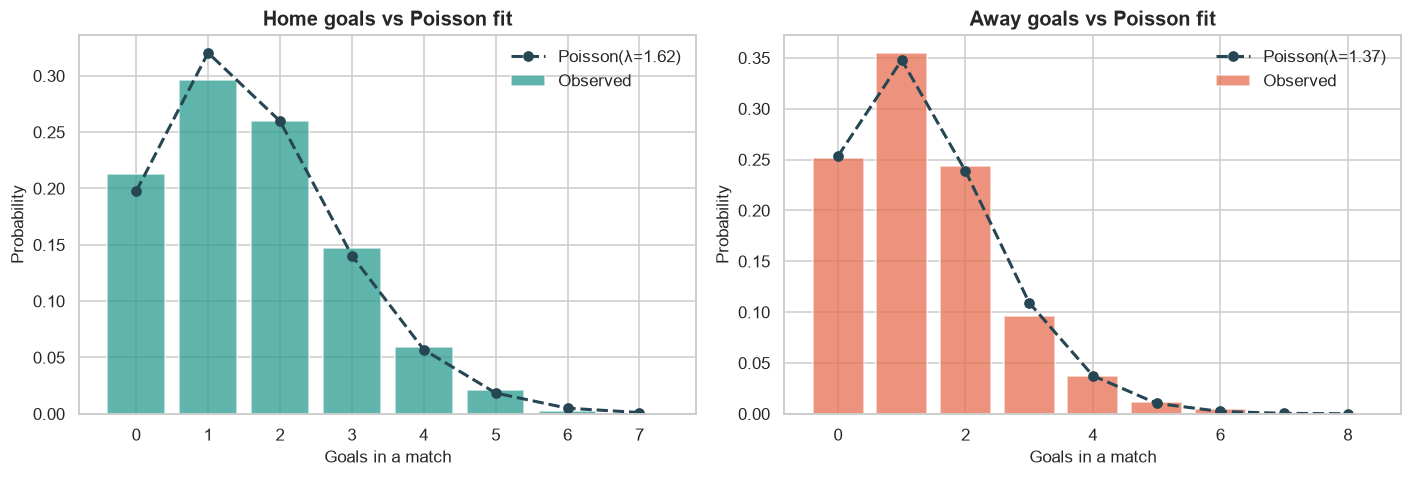

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (side, label, color) in zip(
    axes,
    [("home_goals", "Home goals", "#2a9d8f"), ("away_goals", "Away goals", "#e76f51")],
):
    observed = played[side].value_counts(normalize=True).sort_index()
    lam = played[side].mean()
    k = np.arange(0, observed.index.max() + 1)
    expected = stats.poisson.pmf(k, lam)

    ax.bar(observed.index, observed.values, color=color, alpha=0.75,
           edgecolor="white", label="Observed")
    ax.plot(k, expected, "o--", color="#264653", linewidth=2, markersize=6,
            label=f"Poisson(λ={lam:.2f})")
    ax.set_title(f"{label} vs Poisson fit")
    ax.set_xlabel("Goals in a match")
    ax.set_ylabel("Probability")
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [12]:
# Formal goodness-of-fit test.
# H0: goals follow a Poisson distribution with the observed mean.
for side, label in [("home_goals", "Home"), ("away_goals", "Away")]:
    goals = played[side]
    lam = goals.mean()
    max_k = int(goals.max())

    observed = np.array([(goals == k).sum() for k in range(max_k + 1)], dtype=float)
    probs = stats.poisson.pmf(np.arange(max_k + 1), lam)
    probs[-1] += 1 - probs.sum()  # absorb the tail into the last bin
    expected = probs * len(goals)

    # Merge sparse bins so the chi-square approximation stays valid.
    while len(expected) > 2 and expected[-1] < 5:
        observed[-2] += observed[-1]; observed = observed[:-1]
        expected[-2] += expected[-1]; expected = expected[:-1]

    chi2, p = stats.chisquare(observed, expected, ddof=1)
    verdict = "consistent with Poisson" if p > 0.05 else "deviates from Poisson"
    print(f"{label:<6} goals — mean={lam:.3f}  var={goals.var():.3f}  "
          f"chi2={chi2:.2f}  p={p:.3f}  →  {verdict}")

Home   goals — mean=1.622  var=1.643  chi2=5.97  p=0.309  →  consistent with Poisson
Away   goals — mean=1.372  var=1.421  chi2=3.60  p=0.463  →  consistent with Poisson


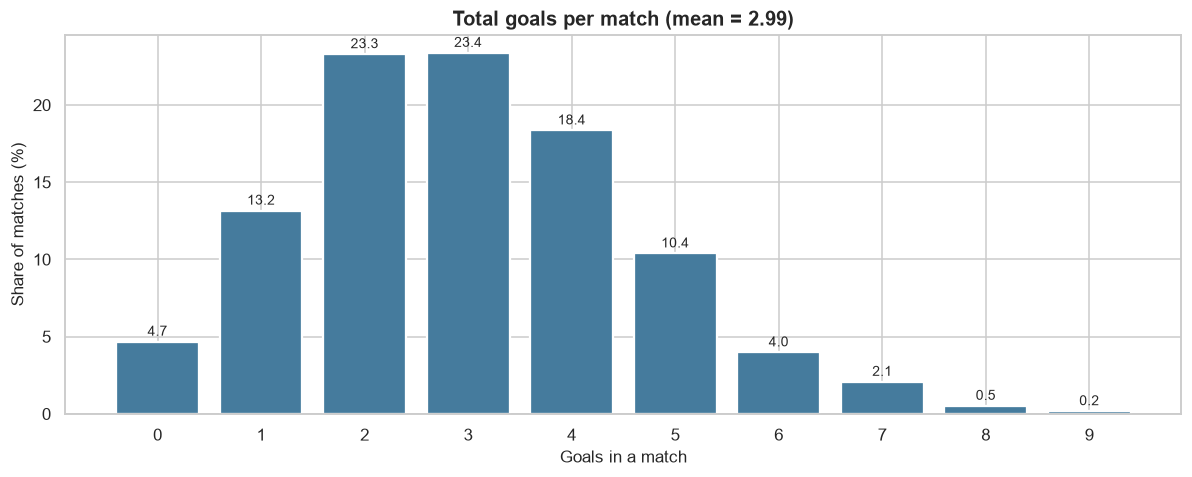

Matches with 2.5+ goals: 58.9%
Goalless draws:          4.7%
Both teams scored:       58.3%


In [13]:
# Total goals per match — relevant for over/under markets and as a model sanity check.
totals = played["total_goals"]

fig, ax = plt.subplots(figsize=(11, 4.5))
counts = totals.value_counts(normalize=True).sort_index()
bars = ax.bar(counts.index, counts.values * 100, color="#457b9d",
              edgecolor="white", linewidth=1.5)
ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=9)
ax.set_title(f"Total goals per match (mean = {totals.mean():.2f})")
ax.set_xlabel("Goals in a match")
ax.set_ylabel("Share of matches (%)")
ax.set_xticks(range(0, int(totals.max()) + 1))
plt.tight_layout()
plt.show()

print(f"Matches with 2.5+ goals: {(totals > 2.5).mean() * 100:.1f}%")
print(f"Goalless draws:          {(totals == 0).mean() * 100:.1f}%")
print(f"Both teams scored:       {((played['home_goals'] > 0) & (played['away_goals'] > 0)).mean() * 100:.1f}%")

## 6. Team strength

Attack and defense ratings per team. These are the features a model will learn from — the
spread between teams is what makes prediction possible at all.

In [14]:
def team_table(data: pd.DataFrame) -> pd.DataFrame:
    """Build a per-team summary from the match-level table."""
    home = data.rename(columns={
        "home_team": "team", "home_goals": "scored", "away_goals": "conceded"
    })[["team", "scored", "conceded", "season"]]
    home["venue"] = "home"

    away = data.rename(columns={
        "away_team": "team", "away_goals": "scored", "home_goals": "conceded"
    })[["team", "scored", "conceded", "season"]]
    away["venue"] = "away"

    return pd.concat([home, away], ignore_index=True)


long = team_table(played)

teams = (
    long.groupby("team")
    .agg(matches=("scored", "size"),
         goals_for=("scored", "sum"),
         goals_against=("conceded", "sum"))
    .assign(
        gf_per_match=lambda d: (d["goals_for"] / d["matches"]).round(2),
        ga_per_match=lambda d: (d["goals_against"] / d["matches"]).round(2),
        goal_diff=lambda d: d["goals_for"] - d["goals_against"],
    )
    .sort_values("goal_diff", ascending=False)
)

teams.head(12)

,matches,goals_for,goals_against,gf_per_match,ga_per_match,goal_diff
team,,,,,,
Arsenal FC,115,234.0,90.0,2.03,0.78,144.0
Manchester City FC,116,251.0,115.0,2.16,0.99,136.0
Liverpool FC,115,237.0,137.0,2.06,1.19,100.0
Chelsea FC,116,206.0,163.0,1.78,1.41,43.0
Newcastle United FC,115,208.0,166.0,1.81,1.44,42.0
Aston Villa FC,115,190.0,165.0,1.65,1.43,25.0
Brighton & Hove Albion FC,116,180.0,171.0,1.55,1.47,9.0
Manchester United FC,116,175.0,166.0,1.51,1.43,9.0
Brentford FC,116,181.0,175.0,1.56,1.51,6.0


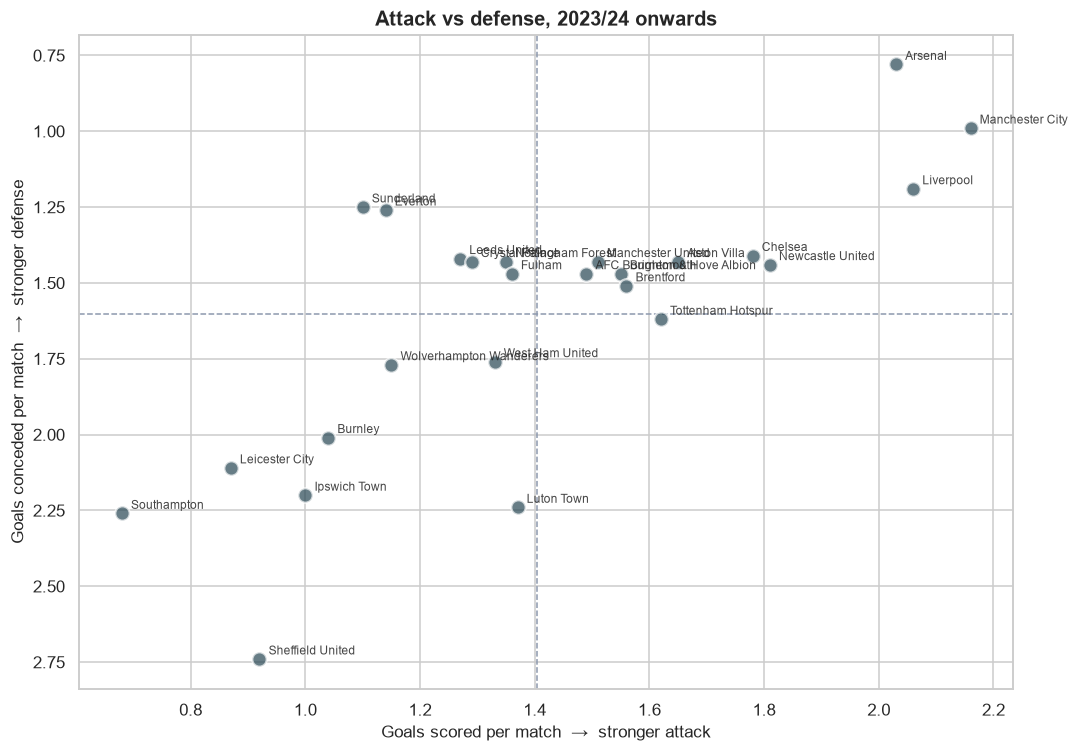

In [15]:
# Attack vs defense — the clearest single view of the competitive landscape.
regulars = teams[teams["matches"] >= 38]  # at least one full season in the window

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(regulars["gf_per_match"], regulars["ga_per_match"],
           s=90, c="#264653", alpha=0.7, edgecolor="white", linewidth=1.5, zorder=3)

for team, row in regulars.iterrows():
    short = team.replace(" FC", "").replace(" AFC", "")
    ax.annotate(short, (row["gf_per_match"], row["ga_per_match"]),
                fontsize=8, xytext=(6, 3), textcoords="offset points", alpha=0.85)

ax.axvline(regulars["gf_per_match"].mean(), color="#8d99ae", ls="--", lw=1, zorder=1)
ax.axhline(regulars["ga_per_match"].mean(), color="#8d99ae", ls="--", lw=1, zorder=1)
ax.invert_yaxis()  # better defenses (fewer conceded) appear at the top
ax.set_xlabel("Goals scored per match  →  stronger attack")
ax.set_ylabel("Goals conceded per match  →  stronger defense")
ax.set_title("Attack vs defense, 2023/24 onwards")
plt.tight_layout()
plt.show()

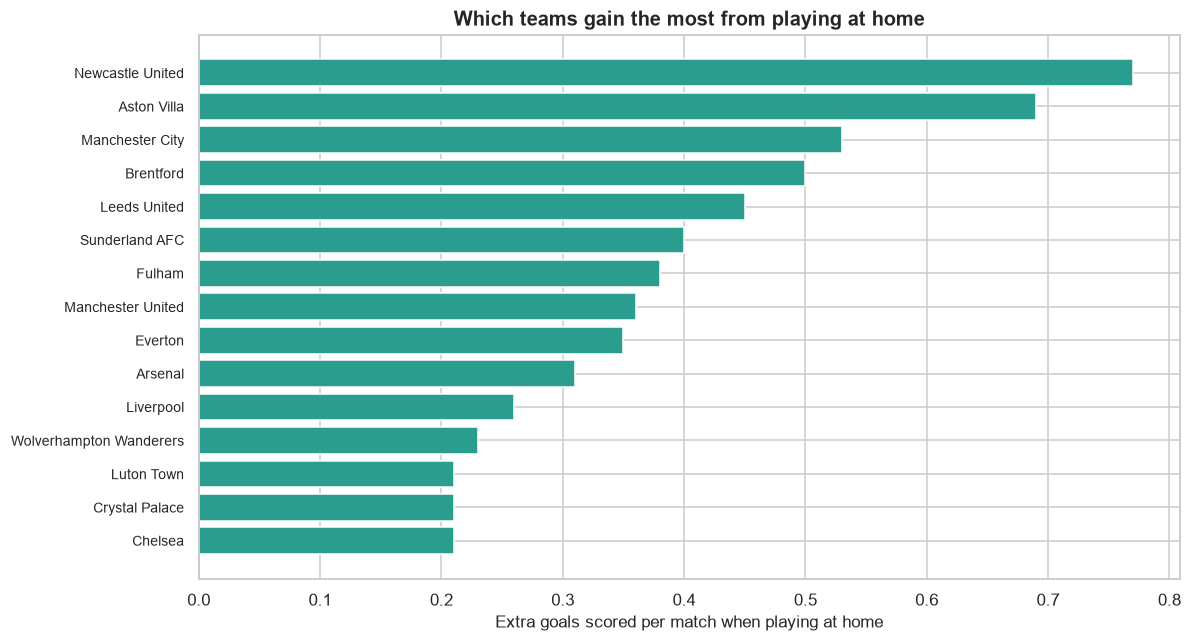

In [16]:
# Home advantage is not uniform — some teams rely on it far more than others.
venue_split = (
    long.groupby(["team", "venue"])["scored"].mean().unstack()
    .assign(home_edge=lambda d: (d["home"] - d["away"]).round(2))
    .sort_values("home_edge", ascending=False)
)
venue_split = venue_split[venue_split.index.isin(regulars.index)]

fig, ax = plt.subplots(figsize=(11, 6))
top = venue_split.head(15)
y = np.arange(len(top))
ax.barh(y, top["home_edge"],
        color=np.where(top["home_edge"] > 0, "#2a9d8f", "#e76f51"),
        edgecolor="white", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([t.replace(" FC", "") for t in top.index], fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color="#264653", lw=1)
ax.set_xlabel("Extra goals scored per match when playing at home")
ax.set_title("Which teams gain the most from playing at home")
plt.tight_layout()
plt.show()

## 7. Temporal patterns

Does scoring change across the season?

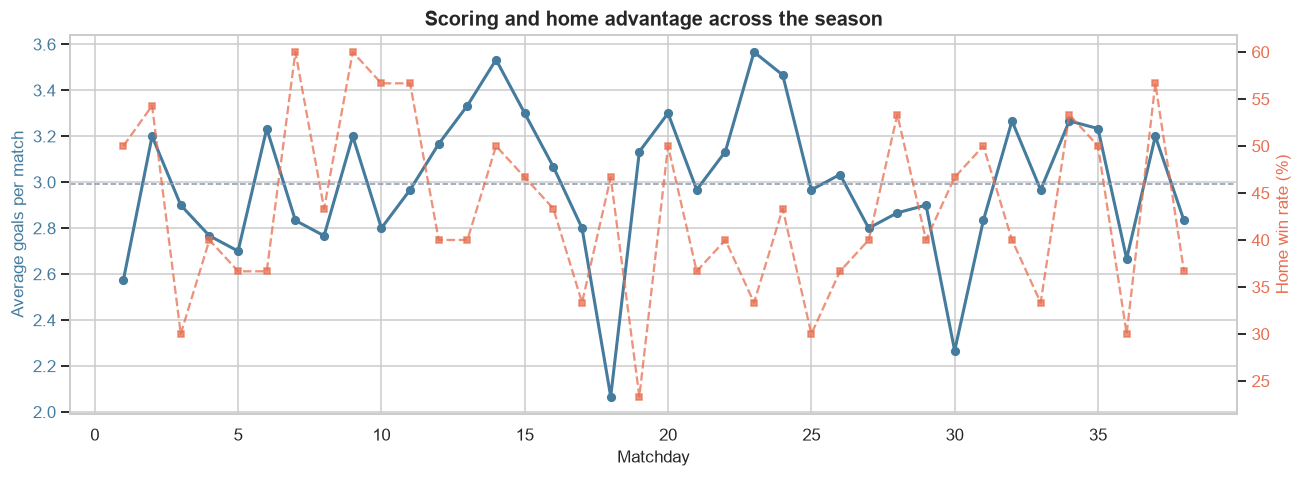

In [17]:
by_matchday = played.groupby("matchday").agg(
    avg_goals=("total_goals", "mean"),
    home_win_rate=("result", lambda s: (s == "H").mean() * 100),
)

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(by_matchday.index, by_matchday["avg_goals"],
         "o-", color="#457b9d", linewidth=2, markersize=5, label="Avg goals")
ax1.axhline(played["total_goals"].mean(), color="#8d99ae", ls="--", lw=1)
ax1.set_xlabel("Matchday")
ax1.set_ylabel("Average goals per match", color="#457b9d")
ax1.tick_params(axis="y", labelcolor="#457b9d")

ax2 = ax1.twinx()
ax2.plot(by_matchday.index, by_matchday["home_win_rate"],
         "s--", color="#e76f51", linewidth=1.5, markersize=4, alpha=0.75)
ax2.set_ylabel("Home win rate (%)", color="#e76f51")
ax2.tick_params(axis="y", labelcolor="#e76f51")
ax2.grid(False)

ax1.set_title("Scoring and home advantage across the season")
plt.tight_layout()
plt.show()

## 8. What this means for modeling

Summary of the findings that shape the next stage of the project.

In [18]:
home_win_rate = (played["result"] == "H").mean()
draw_rate = (played["result"] == "D").mean()
away_win_rate = (played["result"] == "A").mean()

print("KEY FINDINGS")
print("=" * 62)
print(f"Matches analysed              {len(played):,}")
print(f"Seasons covered               {played['season'].nunique()}")
print()
print(f"Home win rate                 {home_win_rate:6.1%}")
print(f"Draw rate                     {draw_rate:6.1%}")
print(f"Away win rate                 {away_win_rate:6.1%}")
print()
print(f"Goals per match (home)        {played['home_goals'].mean():.3f}")
print(f"Goals per match (away)        {played['away_goals'].mean():.3f}")
print(f"Home advantage                {played['home_goals'].mean() - played['away_goals'].mean():+.3f} goals")
print()
print(f"Baseline to beat              {max(home_win_rate, draw_rate, away_win_rate):.1%} "
      f"(always predict the most common outcome)")
print("=" * 62)

KEY FINDINGS
Matches analysed              1,155
Seasons covered               4

Home win rate                  43.5%
Draw rate                      24.3%
Away win rate                  32.2%

Goals per match (home)        1.622
Goals per match (away)        1.372
Home advantage                +0.249 goals

Baseline to beat              43.5% (always predict the most common outcome)


### Modeling implications

1. **Home advantage is substantial and must be an explicit model term.** It is not noise
   to be averaged away; it is one of the strongest signals in the dataset.

2. **Goal counts are close to Poisson.** This supports a bivariate Poisson or Dixon–Coles
   approach, where each team gets an attack and a defense parameter and home advantage
   enters as a fixed effect. The model choice follows from the data, not from convenience.

3. **The naive baseline is the accuracy floor.** Any model that fails to beat "always predict
   a home win" is adding complexity without value. This is the number to report against.

4. **Team strength varies widely.** The spread in the attack–defense plot is what makes the
   problem learnable — with 20 evenly matched teams there would be nothing to predict.

### Next step

Build the match outcome model in `notebooks/02_outcome_model.ipynb`, using a Poisson
regression with team attack/defense parameters and a home-advantage term, evaluated against
the baseline established above.